In [15]:
import numpy as np

# Training data: AND gate
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1]) 

In [16]:
# Perceptron parameters
weights = np.zeros(2)
bias    = 0
lr      = 0.1           # learning rate
epochs  = 10


In [17]:
weights.shape

(2,)

In [18]:
def step(z):
    return 1 if z >= 0 else 0

In [19]:
for epoch in range(epochs):
    errors = 0
    for xi, yi in zip(X, y):
        z    = np.dot(weights, xi) + bias
        pred = step(z)
        err  = yi - pred            # error
        weights += lr * err * xi    # weight update
        bias    += lr * err
        errors  += int(err != 0)
    print(f"Epoch {epoch+1}: errors={errors}, w={weights}, b={bias:.1f}")

Epoch 1: errors=2, w=[0.1 0.1], b=0.0
Epoch 2: errors=3, w=[0.2 0.1], b=-0.1
Epoch 3: errors=3, w=[0.2 0.1], b=-0.2
Epoch 4: errors=0, w=[0.2 0.1], b=-0.2
Epoch 5: errors=0, w=[0.2 0.1], b=-0.2
Epoch 6: errors=0, w=[0.2 0.1], b=-0.2
Epoch 7: errors=0, w=[0.2 0.1], b=-0.2
Epoch 8: errors=0, w=[0.2 0.1], b=-0.2
Epoch 9: errors=0, w=[0.2 0.1], b=-0.2
Epoch 10: errors=0, w=[0.2 0.1], b=-0.2


In [20]:
# Test
print("\n--- Predictions ---")
for xi, yi in zip(X, y):
    pred = step(np.dot(weights, xi) + bias)
    print(f"Input {xi} → pred={pred}, actual={yi}")


--- Predictions ---
Input [0 0] → pred=0, actual=0
Input [0 1] → pred=0, actual=0
Input [1 0] → pred=0, actual=0
Input [1 1] → pred=1, actual=1


In [21]:
print(weights)

[0.2 0.1]


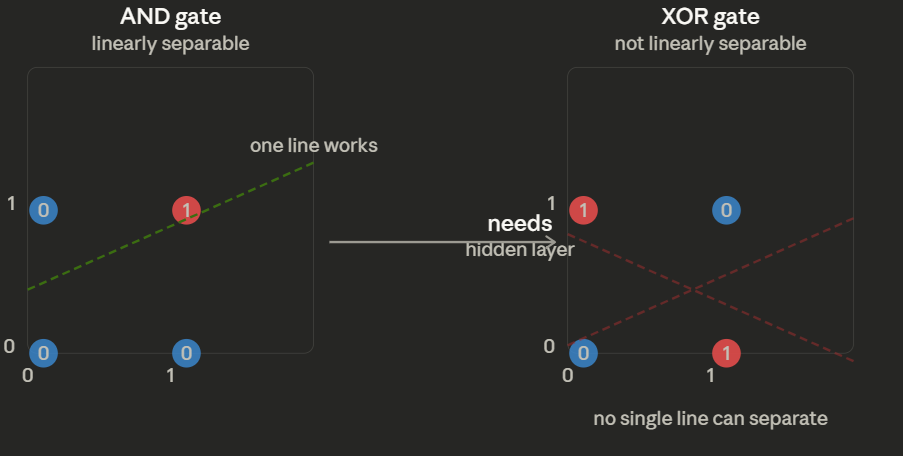

MLP FOR XOR


In [22]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])   # XOR labels

In [23]:
# Architecture: 2 → 2 → 1
np.random.seed(42)
W1 = np.random.randn(2, 2) * 0.5
b1 = np.zeros((1, 2))
W2 = np.random.randn(2, 1) * 0.5
b2 = np.zeros((1, 1))

In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1 - a)

In [25]:
lr = 0.5

In [26]:
for epoch in range(10000):
    # Forward pass
    Z1 = X @ W1 + b1    #Z1 = np.dot(X, W1) + b1 equivalent
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    loss = np.mean((y - A2) ** 2)
    print(loss)


0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126
0.25115581219599126


In [27]:
  # Backpropagation
  dA2 = -2 * (y - A2) / 4
  dZ2 = dA2 * sigmoid_deriv(A2)
  dW2 = A1.T @ dZ2
  db2 = dZ2.sum(axis=0, keepdims=True)

  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * sigmoid_deriv(A1)
  dW1 = X.T @ dZ1
  db1 = dZ1.sum(axis=0, keepdims=True)


In [28]:

dA1

array([[-0.0068659 , -0.00686542],
       [ 0.00781412,  0.00781357],
       [ 0.00773517,  0.00773463],
       [-0.00671975, -0.00671928]])

In [29]:
# Gradient descent
W2 -=lr * dW2
b2 -=lr * db2
W1 -=lr * dW1
b1 -=lr * db1

In [30]:
if epoch % 1000 == 0:
  print(f"Epoch {epoch:5d}: loss={loss:.4f}")

print("\nFinal predictions:")
print(np.round(A2, 3))


Final predictions:
[[0.471]
 [0.463]
 [0.469]
 [0.462]]


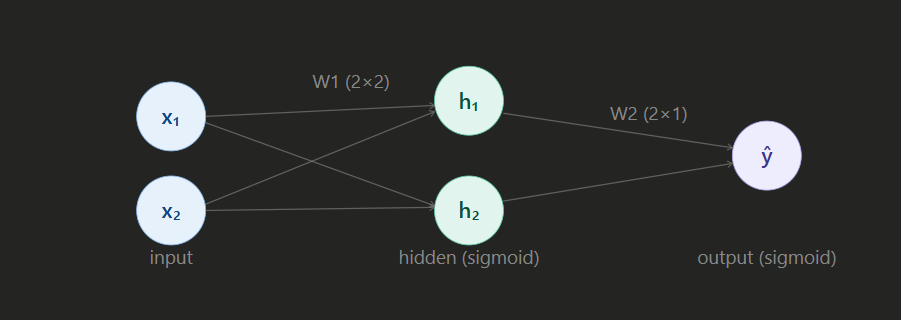